Используя шаблон ноутбука для распознавания видов одежды и аксессуаров из набора **fashion_mnist**, выполните следующие действия:

1. Создайте **9** моделей нейронной сети с различными архитектурами и сравните в них значения точности на проверочной выборке (на последней эпохе) и на тестовой выборке.  Используйте следующее деление: обучающая выборка - **50000** примеров, проверочная выборка - **10000** примеров, тестовая выборка - **10000** примеров.

2. Создайте сравнительную таблицу в конце ноутбука, напишите свои выводы по результатам проведенных тестов.

In [ ]:
# Последовательная модель НС
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization

# Утилиты для to_categorical()
from tensorflow.keras import utils

# Алгоритмы оптимизации для обучения модели
from tensorflow.keras.optimizers import Adam, Adadelta

# Библиотека для работы с массивами
import numpy as np

# Библиотека для работы с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Связь с google-диском
from google.colab import files

# Предварительная обработка данных
from sklearn import preprocessing

# Разделение данных на выборки
from sklearn.model_selection import train_test_split

# Для загрузки датасета
from keras.datasets import fashion_mnist

# Отрисовывать изображения в ноутбуке, а не в консоль или файл
%matplotlib inline

In [ ]:
class Models:
  def __init__(self, epochs = 10, batch_size = 128):
    self.epochs = epochs
    self.batch_size = batch_size

  def load_data(self):
    # Загрузка набора данных
    (x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()
    # Преобразование изображения 28х28 в вектор элементов
    x_train_full = x_train_full.reshape(60000, 784).astype('float32') / 255.0
    x_test = x_test.reshape(10000, 784).astype('float32') / 255.0
    # Деление выборки
    x_train = x_train_full[:50000] # обучающие
    y_train = y_train_full[:50000]

    x_val = x_train_full[50000:] # проверочные
    y_val = y_train_full[50000:]

    # Перевод ответов в категориальный вид
    y_train = utils.to_categorical(y_train, 10)
    y_val = utils.to_categorical(y_val, 10)
    y_test = utils.to_categorical(y_test, 10)

    return x_train, y_train, x_val, y_val, x_test, y_test

  def create_model(self, neurons):
    model = Sequential()

    # Входной слой и скрытый
    model.add(Dense(neurons, input_dim=784, activation="relu"))
    # Выходной слой
    model.add(Dense(10, activation="softmax"))
    # Компиляция модели
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

    return model

  def results(self):
      # Получение данных
      x_train, y_train, x_val, y_val, x_test, y_test = self.load_data()
      neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]
      results = []
      history = {}

      # обучение
      for neurons in neuron_types:
        print('Количество нейронов в обучении: ', neurons)
        model = self.create_model(neurons)
        trained = model.fit(x_train, y_train, batch_size=self.batch_size, epochs=self.epochs, verbose=1, validation_data=(x_val, y_val))

        # проверка качества на обучающей выборке
        loss_test, accuracy_test = model.evaluate(x_test, y_test, verbose=0)
        history[neurons] = trained.history

        results.append({
            "Нейроны": neurons,
            "Точность на обучающей выборке": trained.history['accuracy'][-1],
            "Точность на тестовой выборке": accuracy_test,
            "Точность на валидационной выборке": trained.history['val_accuracy'][-1],
            "Ошибка на обучающей выборке": trained.history['loss'][-1],
            "Ошибка на тестовой выборке": trained.history['loss'][-1],
            "Ошибка на валидационной выборке": loss_test
            })

      df = pd.DataFrame(results)
      return df, history

In [ ]:
m1 = Models(epochs = 10, batch_size = 128)
df, history = m1.results()


Количество нейронов в обучении:  32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7727 - loss: 0.6801 - val_accuracy: 0.8367 - val_loss: 0.4831
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8425 - loss: 0.4584 - val_accuracy: 0.8459 - val_loss: 0.4465
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8553 - loss: 0.4188 - val_accuracy: 0.8485 - val_loss: 0.4293
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8612 - loss: 0.3961 - val_accuracy: 0.8562 - val_loss: 0.4053
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8679 - loss: 0.3766 - val_accuracy: 0.8622 - val_loss: 0.3937
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8715 - loss: 0.3632 - val_accuracy: 0.8642 - val_loss: 0.3844
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8760 - loss: 0.3519 - val_accuracy: 0.8619 - val_loss: 0.4028
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8787 - loss: 0.3403 - val_accuracy: 0.

,Нейроны,Точность на обучающей выборке,Точность на тестовой выборке,Точность на валидационной выборке,Ошибка на обучающей выборке,Ошибка на тестовой выборке,Ошибка на валидационной выборке
0,32,0.8591,0.88420,0.8693,0.395291,0.325444,0.374346
1,64,0.8687,0.89290,0.8776,0.376641,0.296411,0.353707
2,128,0.8755,0.90162,0.8808,0.349224,0.270566,0.326636
3,256,0.8766,0.91102,0.8853,0.346395,0.243670,0.319181
4,512,0.8879,0.91398,0.8892,0.328745,0.232834,0.308208
5,1024,0.8853,0.91706,0.8934,0.327506,0.223864,0.299318
6,70,0.8574,0.89242,0.8661,0.388268,0.295913,0.373189
7,150,0.8723,0.90570,0.8818,0.362406,0.258573,0.341480
8,700,0.8858,0.91746,0.8917,0.330463,0.223120,0.310792


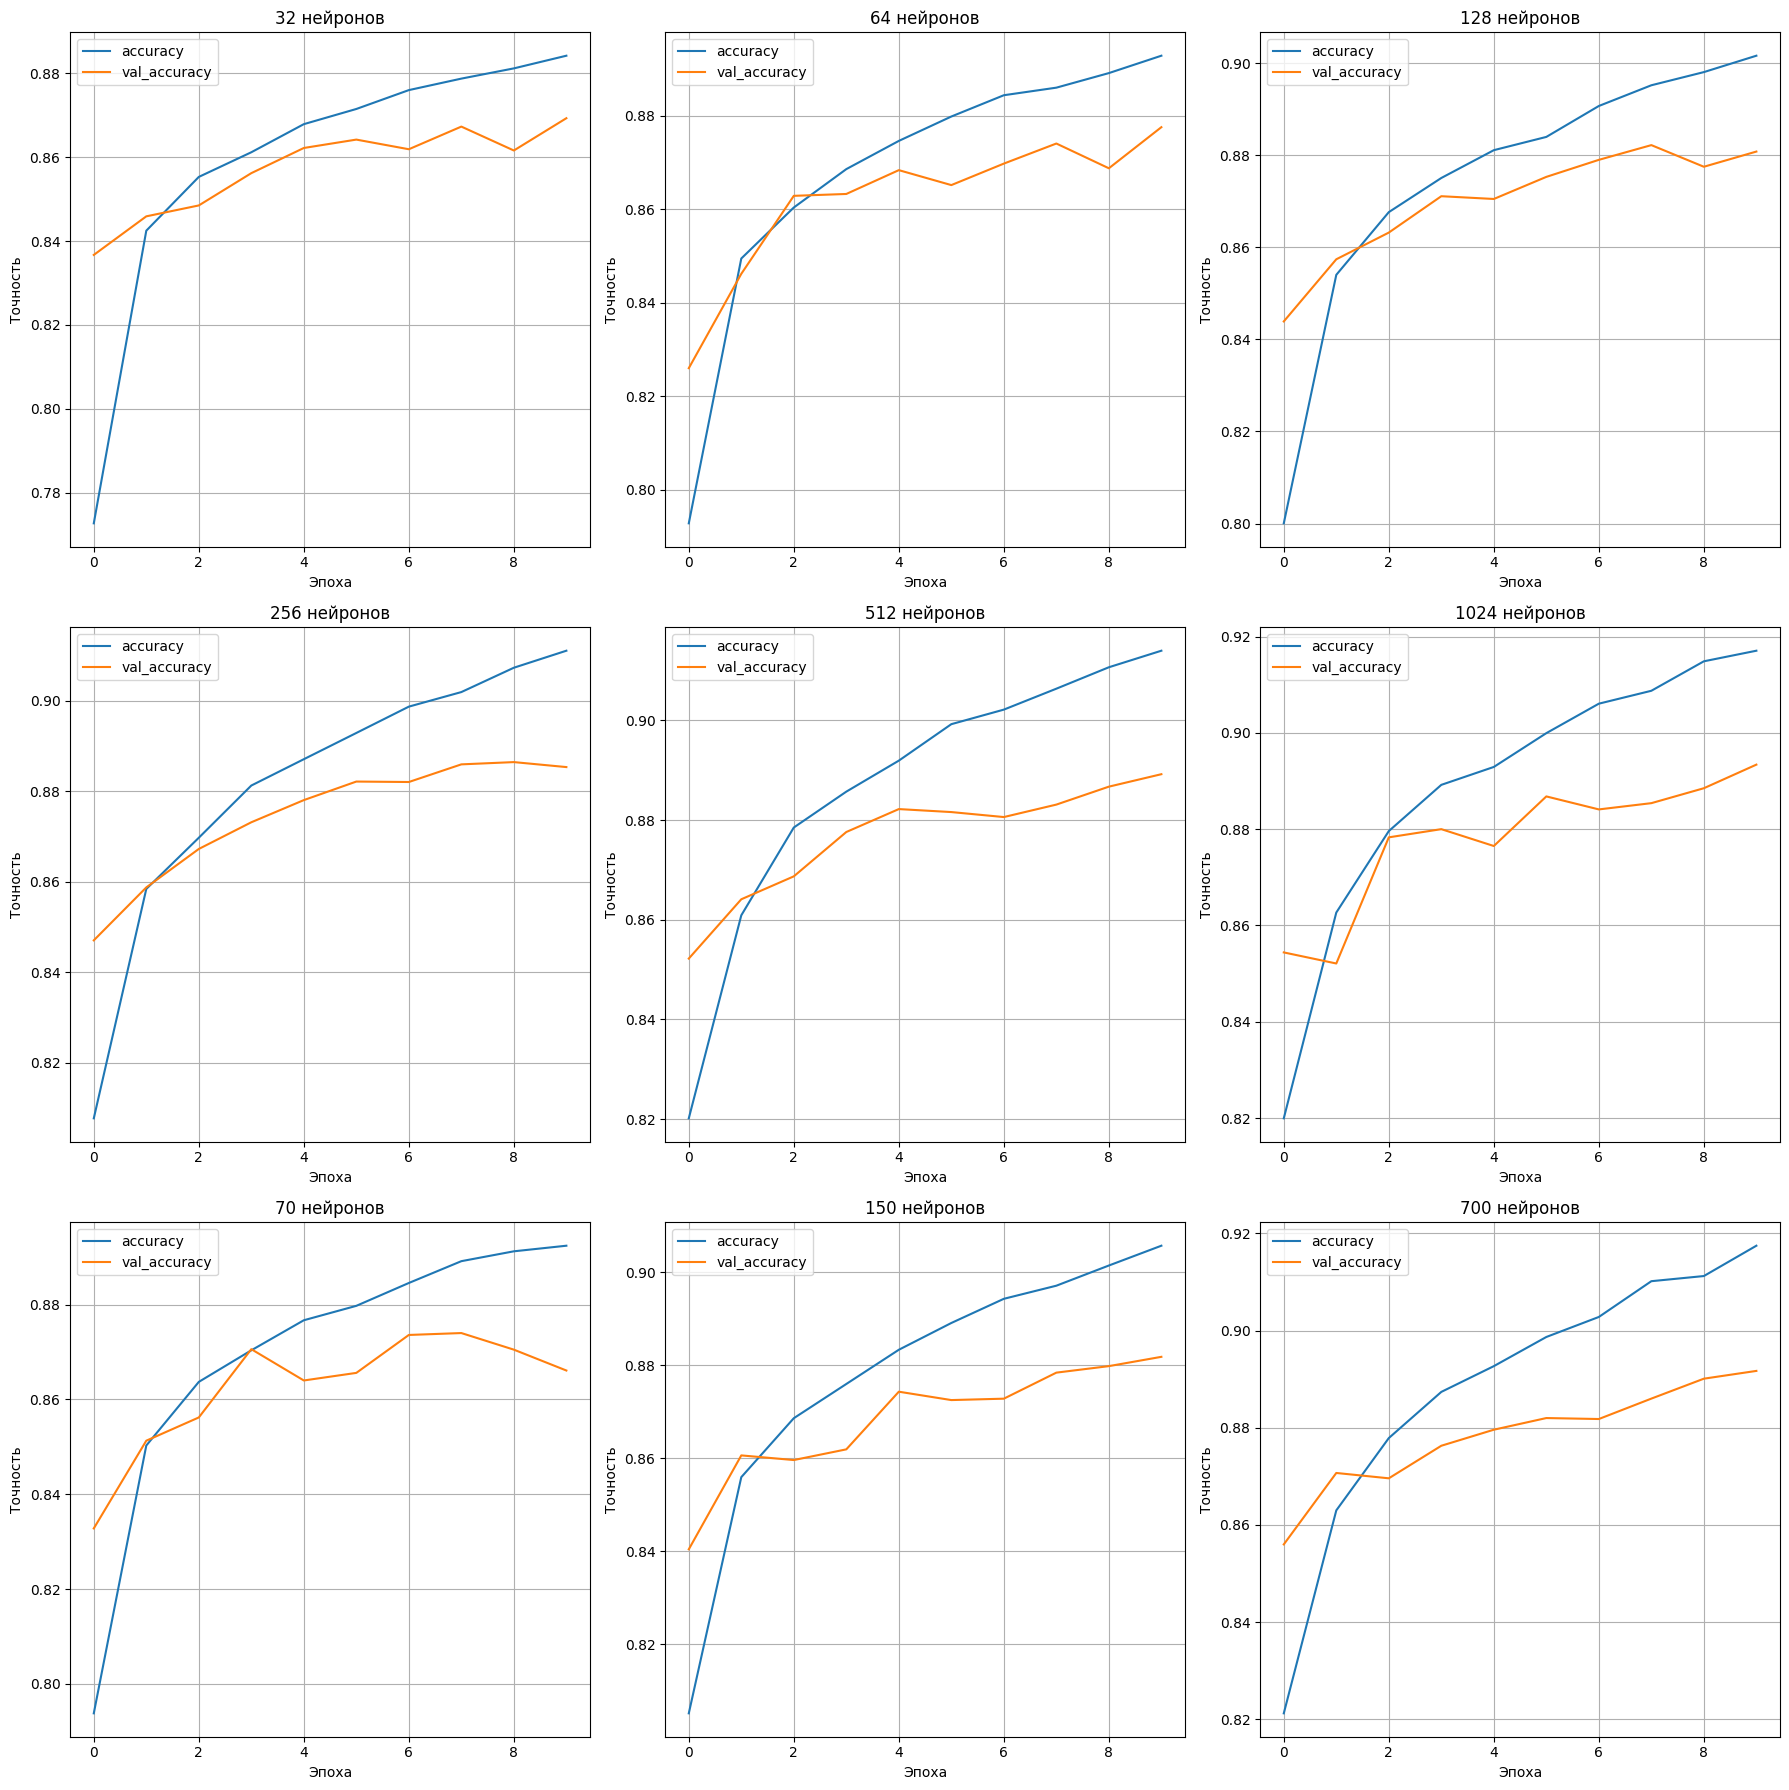

In [ ]:
display(df)

neuron_types = [32, 64, 128, 256, 512, 1024, 70, 150, 700]

fig,axs = plt.subplots(3, 3, figsize = (18, 18))
for i, neurons in enumerate(neuron_types):
  row = i // 3
  col = i % 3

  axs[row, col].set_title(f'{neurons} нейронов')
  axs[row, col].plot(history[neurons]['accuracy'], label = 'accuracy')
  axs[row, col].plot(history[neurons]['val_accuracy'], label = 'val_accuracy')
  axs[row, col].set_xlabel('Эпоха')
  axs[row, col].set_ylabel('Точность')
  axs[row, col].legend()
  axs[row, col].grid(True)

plt.tight_layout()
plt.show()